In [2]:
import pandas as pd
from pathlib import Path

metadata_path = Path(
    r"C:\Users\asus\Desktop\MATLAB_Dataset\Metadata"
)

files = list(metadata_path.glob("*.csv"))

print("CSV sayısı:", len(files))
print("\nİlk 10 dosya:")

for file in files[:10]:
    print(file.name)

# İlk CSV'yi oku
df = pd.read_csv(files[0])

print("\n" + "=" * 60)
print("İLK CSV")
print("=" * 60)

print("\nKolonlar:")
print(df.columns.tolist())

print("\nBoyut:")
print(df.shape)

print("\nİlk 5 satır:")
print(df.head())

CSV sayısı: 408

İlk 10 dosya:
Combined_LTE_DSSS_frame_1.csv
Combined_LTE_DSSS_frame_10.csv
Combined_LTE_DSSS_frame_100.csv
Combined_LTE_DSSS_frame_101.csv
Combined_LTE_DSSS_frame_102.csv
Combined_LTE_DSSS_frame_103.csv
Combined_LTE_DSSS_frame_104.csv
Combined_LTE_DSSS_frame_105.csv
Combined_LTE_DSSS_frame_106.csv
Combined_LTE_DSSS_frame_107.csv

İLK CSV

Kolonlar:
['Signal_Type', 'LTE_BW', 'LTE_OBW', 'LTE_SNR_dB', 'LTE_SR', 'LTE_DSSS_Overlap_Percentage', 'DSSS_OBW', 'DSSS_BW', 'DSSS_RollOff_Factor', 'DSSS_SNR_dB', 'DSSS_PolyDegree_M', 'DSSS_SpreadingGain', 'DSSS_Mod', 'LTE_DSSS_SIR_dB', 'DSSS_SR']

Boyut:
(1, 15)

İlk 5 satır:
  Signal_Type  LTE_BW  LTE_OBW  LTE_SNR_dB   LTE_SR  \
0    LTE_DSSS       5  4500000           0  7680000   

   LTE_DSSS_Overlap_Percentage  DSSS_OBW  DSSS_BW  DSSS_RollOff_Factor  \
0                           25   1125000   750000                  0.5   

   DSSS_SNR_dB  DSSS_PolyDegree_M  DSSS_SpreadingGain DSSS_Mod  \
0            0                 10     

In [3]:
print(df[[
    "Signal_Type",
    "LTE_BW",
    "LTE_SR",
    "DSSS_SR",
    "LTE_SNR_dB",
    "DSSS_SNR_dB",
    "LTE_DSSS_SIR_dB"
]].to_string(index=False))

Signal_Type  LTE_BW  LTE_SR  DSSS_SR  LTE_SNR_dB  DSSS_SNR_dB  LTE_DSSS_SIR_dB
   LTE_DSSS       5 7680000  7680000           0            0                0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# FFT için kullanılacak örnek sayısı
N = 4096

# İlk N IQ örneği
x = iq[:N]

# FFT
X = np.fft.fft(x)

# Frekans ekseni
freq = np.fft.fftfreq(N, d=1/Fs) if "Fs" in globals() else np.fft.fftfreq(N, d=1/7_680_000)

# FFT'yi merkeze al
X_shifted = np.fft.fftshift(X)
freq_shifted = np.fft.fftshift(freq)

# Magnitude
magnitude = np.abs(X_shifted)

# dB
magnitude_db = 20 * np.log10(magnitude + 1e-12)

# Grafik
plt.figure(figsize=(12, 5))

plt.plot(freq_shifted / 1e6, magnitude_db)

plt.title("IQ Signal FFT")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.grid()

plt.show()

NameError: name 'iq' is not defined

In [5]:
import numpy as np
from pathlib import Path

file_path = Path(
    r"C:\Users\asus\Desktop\MATLAB_Dataset\IQ\Combined_LTE_DSSS_frame_1"
)

raw_data = np.fromfile(
    file_path,
    dtype=np.float32,
    offset=8
)

I = raw_data[0::2]
Q = raw_data[1::2]

iq = I + 1j * Q

Fs = 7_680_000

print("IQ samples:", len(iq))
print("Sample rate:", Fs, "Hz")

IQ samples: 614400
Sample rate: 7680000 Hz


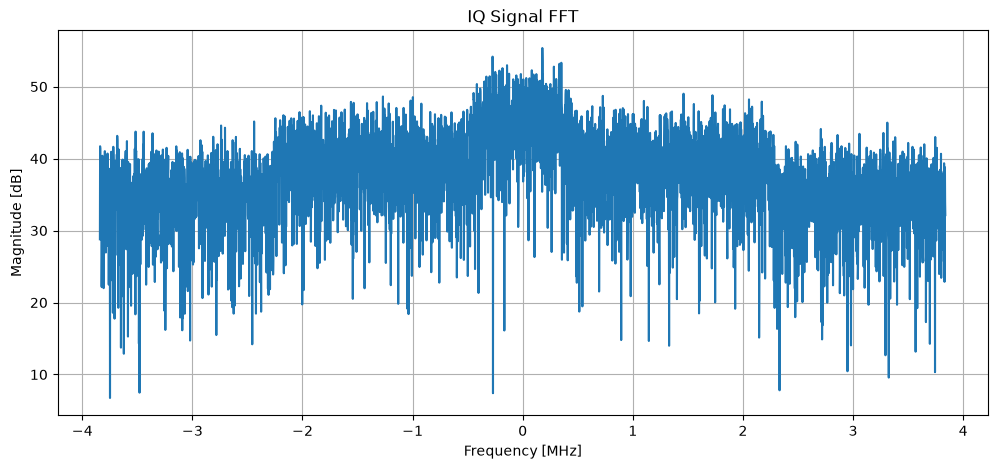

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 4096

x = iq[:N]

X = np.fft.fft(x)

freq = np.fft.fftfreq(N, d=1/Fs)

X_shifted = np.fft.fftshift(X)
freq_shifted = np.fft.fftshift(freq)

magnitude = np.abs(X_shifted)

magnitude_db = 20 * np.log10(magnitude + 1e-12)

plt.figure(figsize=(12, 5))

plt.plot(freq_shifted / 1e6, magnitude_db)

plt.title("IQ Signal FFT")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.grid()

plt.show()

In [7]:
print("FFT size:", N)
print("Frequency resolution:", Fs / N, "Hz")
print("Frequency range:",
      freq_shifted[0] / 1e6,
      "to",
      freq_shifted[-1] / 1e6,
      "MHz")

peak_index = np.argmax(magnitude)
peak_freq = freq_shifted[peak_index]

print("Peak frequency:", peak_freq / 1e6, "MHz")
print("Peak magnitude:", magnitude_db[peak_index], "dB")

FFT size: 4096
Frequency resolution: 1875.0 Hz
Frequency range: -3.84 to 3.838125 MHz
Peak frequency: 0.178125 MHz
Peak magnitude: 55.36651 dB


C:\Users\asus\AppData\Local\Temp\ipykernel_6576\1056685895.py:5: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(


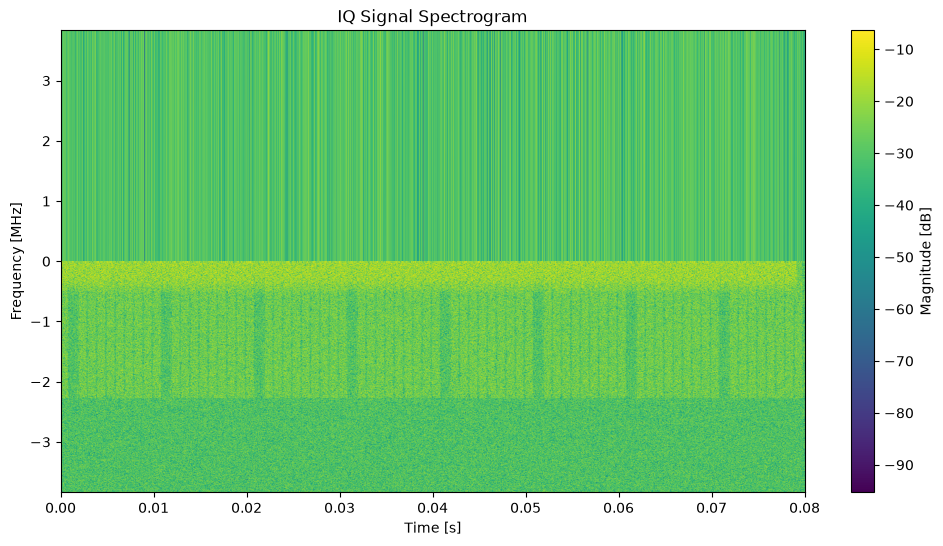

In [8]:
from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np

f, t, Zxx = stft(
    iq,
    fs=Fs,
    window="hann",
    nperseg=1024,
    noverlap=512
)

spectrogram_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    t,
    f / 1e6,
    spectrogram_db,
    shading="gouraud"
)

plt.title("IQ Signal Spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [MHz]")
plt.colorbar(label="Magnitude [dB]")

plt.show()

In [9]:
print("STFT shape:", Zxx.shape)
print("Time bins:", len(t))
print("Frequency bins:", len(f))
print("Frequency range:", f.min(), "to", f.max(), "Hz")

STFT shape: (1024, 1201)
Time bins: 1201
Frequency bins: 1024
Frequency range: -3840000.0 to 3832500.0 Hz


In [10]:
print("STFT shape:", Zxx.shape)
print("Time bins:", len(t))
print("Frequency bins:", len(f))
print("Frequency range:", f.min(), "to", f.max(), "Hz")

STFT shape: (1024, 1201)
Time bins: 1201
Frequency bins: 1024
Frequency range: -3840000.0 to 3832500.0 Hz


C:\Users\asus\AppData\Local\Temp\ipykernel_6576\799121270.py:7: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(


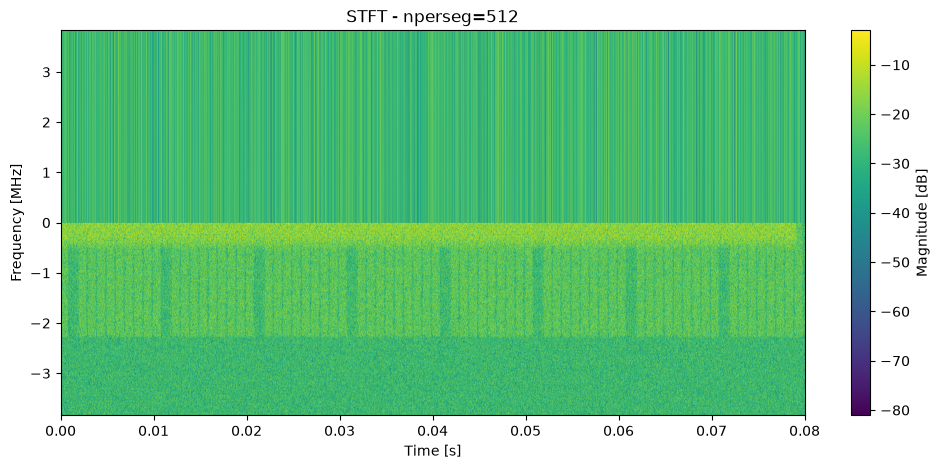

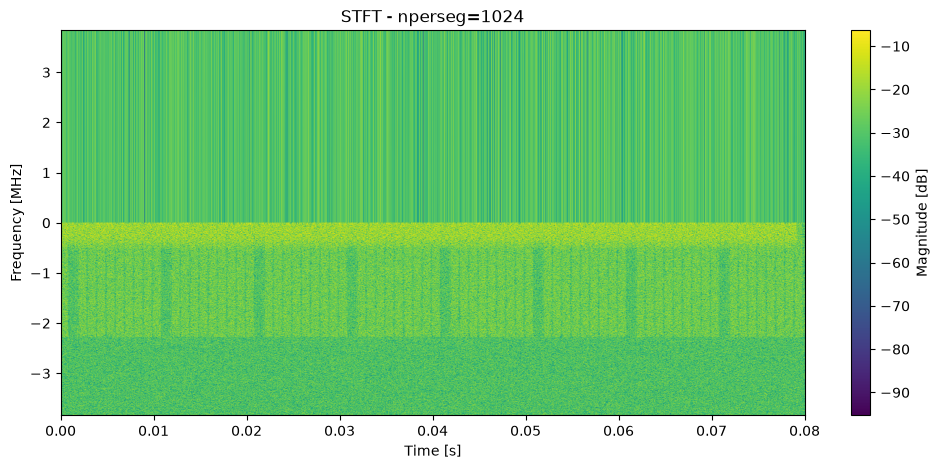

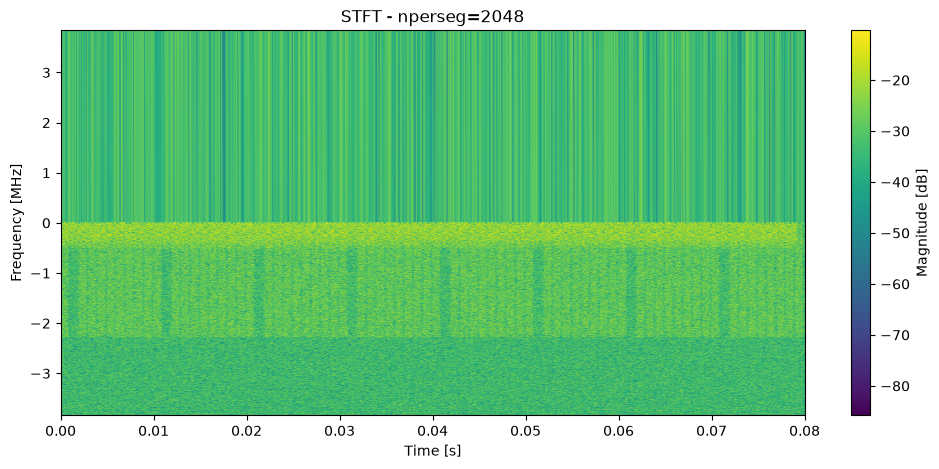

In [11]:
from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np

for nperseg in [512, 1024, 2048]:

    f, t, Zxx = stft(
        iq,
        fs=Fs,
        window="hann",
        nperseg=nperseg,
        noverlap=nperseg // 2
    )

    spectrogram_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

    plt.figure(figsize=(12, 5))
    plt.pcolormesh(
        t,
        f / 1e6,
        spectrogram_db,
        shading="gouraud"
    )

    plt.title(f"STFT - nperseg={nperseg}")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [MHz]")
    plt.colorbar(label="Magnitude [dB]")
    plt.show()

In [12]:
from pathlib import Path

iq_folder = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset\IQ")

files = list(iq_folder.iterdir())

for file in files[:20]:
    print(file.name)

Combined_LTE_DSSS_frame_1
Combined_LTE_DSSS_frame_10
Combined_LTE_DSSS_frame_100
Combined_LTE_DSSS_frame_101
Combined_LTE_DSSS_frame_102
Combined_LTE_DSSS_frame_103
Combined_LTE_DSSS_frame_104
Combined_LTE_DSSS_frame_105
Combined_LTE_DSSS_frame_106
Combined_LTE_DSSS_frame_107
Combined_LTE_DSSS_frame_108
Combined_LTE_DSSS_frame_109
Combined_LTE_DSSS_frame_11
Combined_LTE_DSSS_frame_110
Combined_LTE_DSSS_frame_111
Combined_LTE_DSSS_frame_112
Combined_LTE_DSSS_frame_113
Combined_LTE_DSSS_frame_114
Combined_LTE_DSSS_frame_115
Combined_LTE_DSSS_frame_116


In [13]:
from pathlib import Path

root = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")

for file in root.rglob("*"):
    if file.is_file() and "LTE" in file.name and "DSSS" not in file.name:
        print(file)

C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_1.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_1.NC
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_10.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_10.NC
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_11.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_11.NC
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_12.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_12.NC
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_13.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_13.NC
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_14.C
C:\Users\asus\Desktop\MATLAB_Dataset\CSP_Features\OnlyLTE_frame_100_131072_14.NC
C:\Users\asus\Desktop\MATLAB_Dataset

In [14]:
from scipy.signal import stft
import numpy as np

f, t, Zxx = stft(
    iq,
    fs=Fs,
    window="hann",
    nperseg=1024,
    noverlap=512
)

spectrogram_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

print("STFT min:", spectrogram_db.min(), "dB")
print("STFT max:", spectrogram_db.max(), "dB")

STFT min: -95.327 dB
STFT max: -6.3817024 dB


C:\Users\asus\AppData\Local\Temp\ipykernel_6576\1032388511.py:4: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(


In [ ]:
threshold = -30

mask = spectrogram_db > threshold

print("Threshold:", threshold, "dB")
print("Güçlü bölgelerin oranı:", mask.mean() * 100, "%")

In [15]:
threshold = -30

mask = spectrogram_db > threshold

print("Threshold:", threshold, "dB")
print("Güçlü bölgelerin oranı:", mask.mean() * 100, "%")

Threshold: -30 dB
Güçlü bölgelerin oranı: 67.58251587218984 %


In [16]:
percentiles = np.percentile(
    spectrogram_db,
    [1, 5, 10, 25, 50, 75, 90, 95, 99]
)

for p, value in zip(
    [1, 5, 10, 25, 50, 75, 90, 95, 99],
    percentiles
):
    print(f"{p}% percentile: {value:.2f} dB")

1% percentile: -46.26 dB
5% percentile: -39.14 dB
10% percentile: -35.95 dB
25% percentile: -31.45 dB
50% percentile: -27.21 dB
75% percentile: -23.31 dB
90% percentile: -19.86 dB
95% percentile: -17.78 dB
99% percentile: -13.96 dB


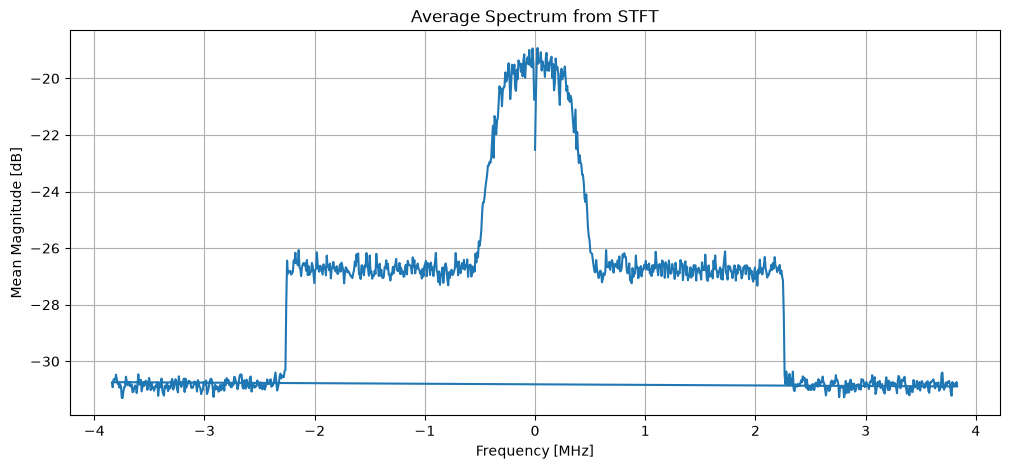

In [17]:
mean_spectrum = np.mean(spectrogram_db, axis=1)

plt.figure(figsize=(12, 5))
plt.plot(f / 1e6, mean_spectrum)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Mean Magnitude [dB]")
plt.title("Average Spectrum from STFT")
plt.grid()
plt.show()

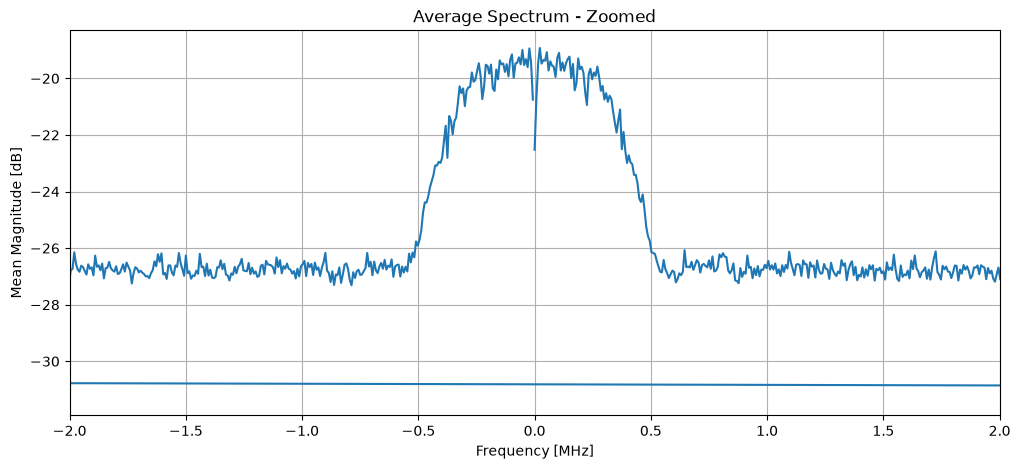

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(f / 1e6, mean_spectrum)

plt.xlim(-2, 2)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Mean Magnitude [dB]")
plt.title("Average Spectrum - Zoomed")
plt.grid()

plt.show()

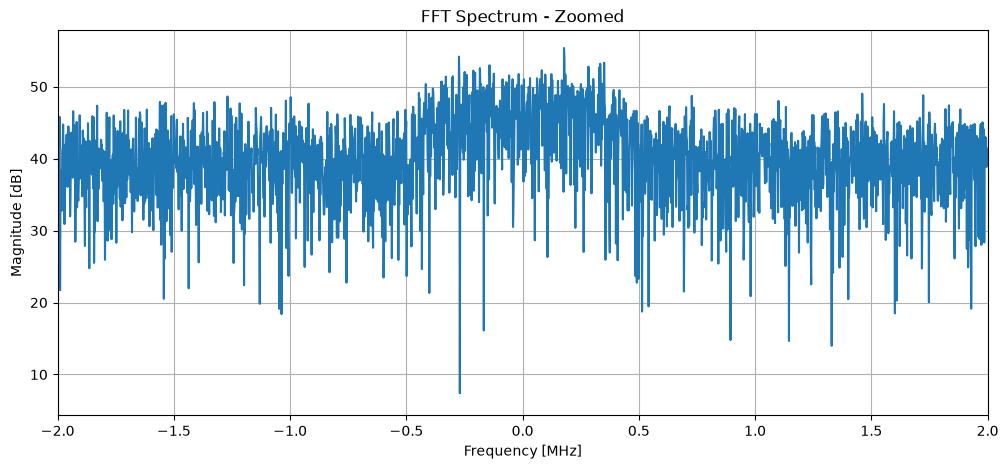

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(freq_shifted / 1e6, magnitude_db)

plt.xlim(-2, 2)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.title("FFT Spectrum - Zoomed")
plt.grid()

plt.show()

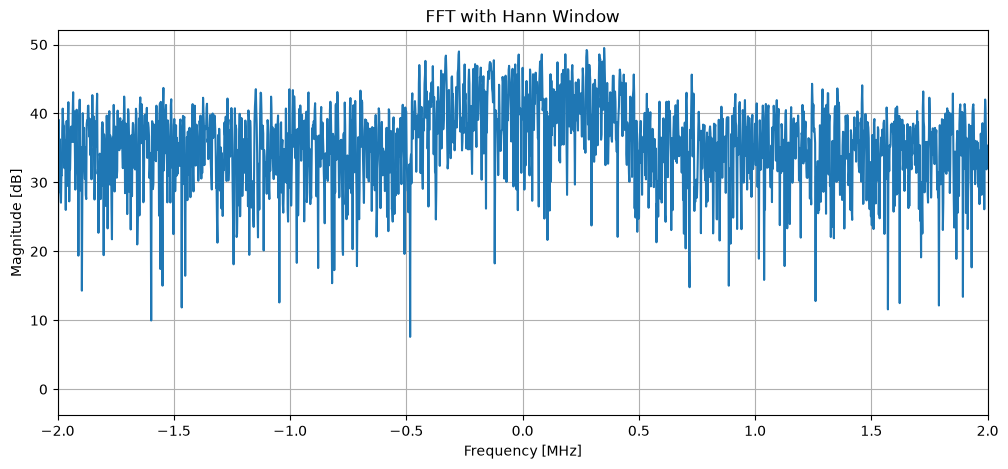

In [20]:
from scipy.signal import windows

x = iq[:N]

window = windows.hann(N)
x_windowed = x * window

X_windowed = np.fft.fft(x_windowed)
X_windowed = np.fft.fftshift(X_windowed)

magnitude_windowed = np.abs(X_windowed)
magnitude_windowed_db = 20 * np.log10(magnitude_windowed + 1e-12)

plt.figure(figsize=(12, 5))

plt.plot(freq_shifted / 1e6, magnitude_windowed_db)

plt.xlim(-2, 2)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.title("FFT with Hann Window")
plt.grid()

plt.show()

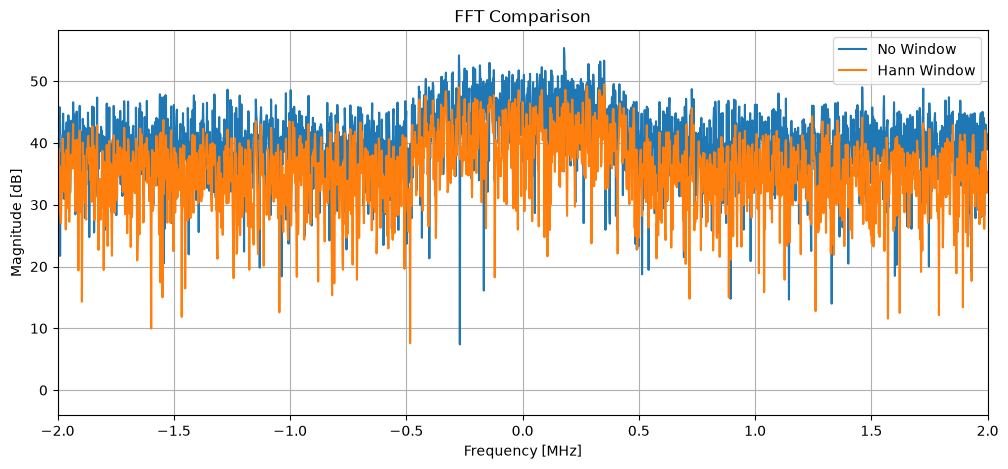

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(freq_shifted / 1e6, magnitude_db, label="No Window")
plt.plot(freq_shifted / 1e6, magnitude_windowed_db, label="Hann Window")

plt.xlim(-2, 2)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Magnitude [dB]")
plt.title("FFT Comparison")
plt.legend()
plt.grid()

plt.show()

In [22]:
for nperseg in [512, 1024, 2048]:

    df = Fs / nperseg
    dt = (nperseg / Fs) / 2

    print(f"nperseg = {nperseg}")
    print(f"Frequency resolution: {df:.2f} Hz")
    print(f"Approx. time step: {dt*1000:.2f} ms")
    print()

nperseg = 512
Frequency resolution: 15000.00 Hz
Approx. time step: 0.03 ms

nperseg = 1024
Frequency resolution: 7500.00 Hz
Approx. time step: 0.07 ms

nperseg = 2048
Frequency resolution: 3750.00 Hz
Approx. time step: 0.13 ms



In [23]:
for nperseg in [512, 1024, 2048]:
    df = Fs / nperseg
    dt = (nperseg / Fs) / 2

    print(f"nperseg = {nperseg}")
    print(f"Frequency resolution: {df:.2f} Hz")
    print(f"Approx. time step: {dt*1000:.2f} ms")
    print()

nperseg = 512
Frequency resolution: 15000.00 Hz
Approx. time step: 0.03 ms

nperseg = 1024
Frequency resolution: 7500.00 Hz
Approx. time step: 0.07 ms

nperseg = 2048
Frequency resolution: 3750.00 Hz
Approx. time step: 0.13 ms



In [24]:
print("Spectrogram shape:", spectrogram_db.shape)

Spectrogram shape: (1024, 1201)


In [25]:
spec_min = spectrogram_db.min()
spec_max = spectrogram_db.max()

spectrogram_norm = (
    spectrogram_db - spec_min
) / (
    spec_max - spec_min
)

print("Min:", spectrogram_norm.min())
print("Max:", spectrogram_norm.max())
print("Shape:", spectrogram_norm.shape)

Min: 0.0
Max: 1.0
Shape: (1024, 1201)


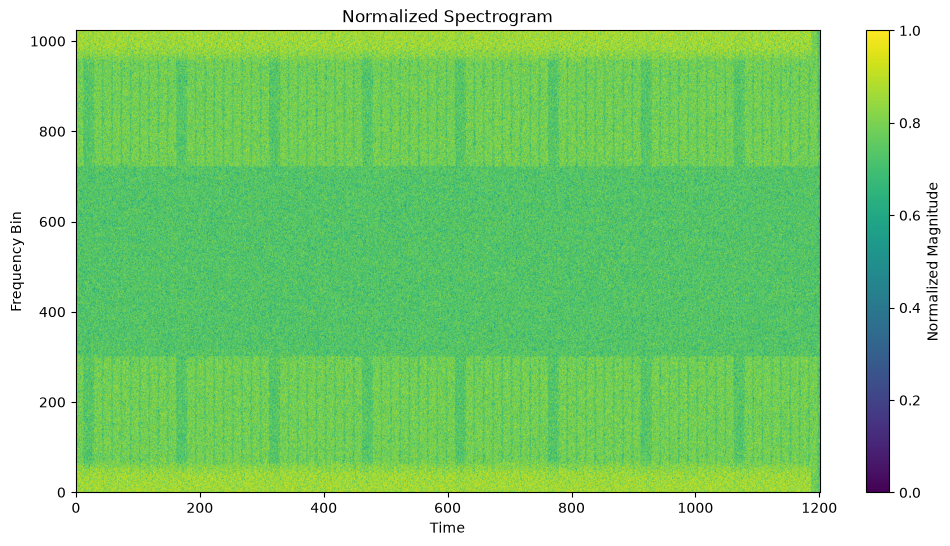

In [26]:
plt.figure(figsize=(12, 6))

plt.imshow(
    spectrogram_norm,
    aspect="auto",
    origin="lower"
)

plt.xlabel("Time")
plt.ylabel("Frequency Bin")
plt.title("Normalized Spectrogram")
plt.colorbar(label="Normalized Magnitude")

plt.show()

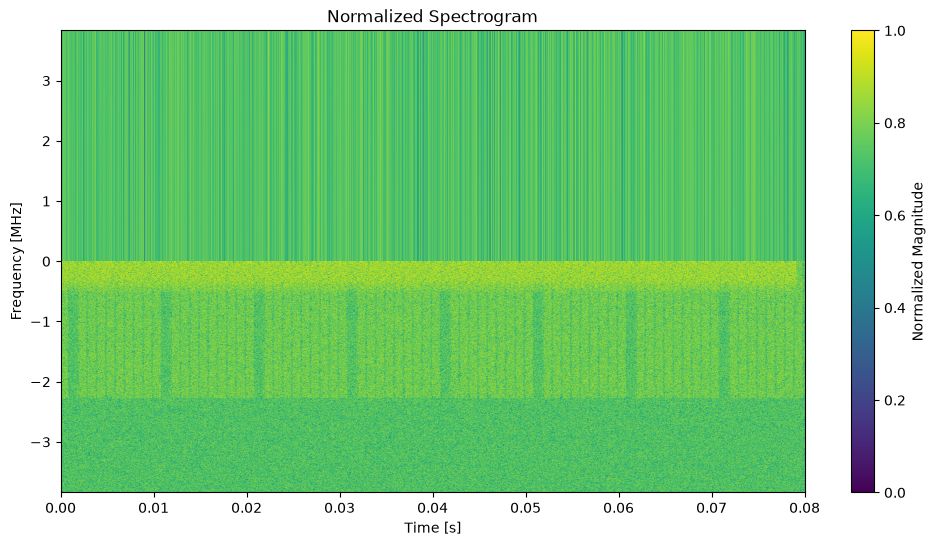

In [27]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    t,
    f / 1e6,
    spectrogram_norm,
    shading="gouraud"
)

plt.xlabel("Time [s]")
plt.ylabel("Frequency [MHz]")
plt.title("Normalized Spectrogram")
plt.colorbar(label="Normalized Magnitude")

plt.show()